In [19]:
import sys
import os
import subprocess
import shutil

# Check if we are running in Google Colab (remote Linux VM)
if 'google.colab' in sys.modules:
    print("Detected Google Colab environment. Setting up via GitHub...")
    
    # 1. Install required packages using PyG pre-compiled wheels to avoid long build times
    import torch
    torch_version = torch.__version__.split('+')[0]
    # Format cuda version, e.g. '12.1' -> 'cu121'
    if torch.version.cuda:
        cuda_version = f"cu{torch.version.cuda.replace('.', '')}"
    else:
        cuda_version = "cpu"
        
    wheel_url = f"https://data.pyg.org/whl/torch-{torch_version}+{cuda_version}.html"
    
    print(f"Installing PyG dependencies from {wheel_url}...")
    subprocess.run(["pip", "install", "-q", "torch_geometric", "prody"], check=True)
    subprocess.run(["pip", "install", "-q", "torch-cluster", "-f", wheel_url], check=True)

    # 2. Clone/update main repository
    repo_url = "https://github.com/WSobo/Struct2Seq-GNN.git"
    target_dir = "/content/Struct2Seq-GNN"

    if not os.path.exists(target_dir):
        os.chdir('/content')
        print("Cloning repository...")
        subprocess.run(["git", "clone", repo_url], check=True)
    else:
        os.chdir(target_dir)
        print("Pulling latest changes...")
        subprocess.run(["git", "fetch", "--all"], check=True)
        subprocess.run(["git", "pull"], check=True)

    # 3. Ensure LigandMPNN dependency exists (fallback for gitlink/submodule issues)
    ligand_dir = os.path.join(target_dir, "LigandMPNN")
    ligand_data_utils = os.path.join(ligand_dir, "data_utils.py")
    if not os.path.exists(ligand_data_utils):
        print("Fetching LigandMPNN dependency...")
        if os.path.exists(ligand_dir):
            shutil.rmtree(ligand_dir)
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/dauparas/LigandMPNN.git", "LigandMPNN"],
            cwd=target_dir,
            check=True,
        )

    # 4. Enter the project directory
    os.chdir(target_dir)
    print("Colab setup complete. Current Dir:", os.getcwd())

Detected Google Colab environment. Setting up via GitHub...
Installing PyG dependencies from https://data.pyg.org/whl/torch-2.10.0+cu128.html...
Pulling latest changes...
Colab setup complete. Current Dir: /content/Struct2Seq-GNN


In [29]:
#@title Which Branch?

!git fetch --all
!git checkout feat/advanced-gnn-features
!git pull origin feat/advanced-gnn-features

Fetching origin
M	LigandMPNN
Already on 'feat/advanced-gnn-features'
Your branch is up to date with 'origin/feat/advanced-gnn-features'.
From https://github.com/WSobo/Struct2Seq-GNN
 * branch            feat/advanced-gnn-features -> FETCH_HEAD
Already up to date.


# Struct2Seq-GNN: Pipeline Testing
This notebook runs the basic sanity checks for the inference and training pipelines of the Struct2Seq-GNN model.

In [21]:
import os
# Ensure we operate from the project root
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print("Current Working Directory:", os.getcwd())

Current Working Directory: /content/Struct2Seq-GNN


## Step 1: Test Inference Pipeline (Sanity Check)
Before training, make sure the model can successfully take a 3D structure, convert it to a graph, run it through the GCN, and output sequence predictions.

In [22]:
import os

# Set PYTHONPATH environment variable so python subprocesses can find project modules
os.environ['PYTHONPATH'] = f"{os.environ.get('PYTHONPATH', '')}:{os.getcwd()}"

# Use an actual PDB file as input for parse_PDB
!python scripts/run.py --pdb LigandMPNN/inputs/1BC8.pdb

Parsing LigandMPNN/inputs/1BC8.pdb...
Predicted Sequence Length: 93
Done!


## Step 2: Test Training Loop
Confirm the data loader can successfully read the LigandMPNN `train.json` splits and start optimizing the weights for a couple of epochs.

In [10]:
import os
import json
import glob

# Build a tiny local split from available input PDBs for a stable smoke test
pdb_files = sorted(glob.glob("LigandMPNN/inputs/*.pdb"))
ids = [os.path.splitext(os.path.basename(p))[0] for p in pdb_files]
if len(ids) < 2:
    raise RuntimeError("Need at least 2 PDB files in LigandMPNN/inputs for train/valid smoke test.")

os.makedirs("training", exist_ok=True)
with open("training/train_smoke.json", "w") as f:
    json.dump([ids[0]], f)
with open("training/valid_smoke.json", "w") as f:
    json.dump([ids[1]], f)

!python scripts/train.py \
    --json_train training/train_smoke.json \
    --json_valid training/valid_smoke.json \
    --pdb_dir LigandMPNN/inputs/ \
    --epochs 2 \
    --batch_size 1

Using device: cuda
Initializing datasets... (This will process raw PDBs into PyG graphs)
Starting training...
Epoch 001 | Train Loss: 3.0889 - Acc: 0.1290 | Val Loss: 3.1938 - Acc: 0.0473
  -> Saved new best model!
Epoch 002 | Train Loss: 2.8067 - Acc: 0.1935 | Val Loss: 3.1770 - Acc: 0.0465
  -> Saved new best model!


In [25]:
import os

# 1. Clear the PyTorch Geometric processed cache.
# This forces the dataset loader to rebuild the graphs from the raw PDBs using our new HETEROGENEOUS graph building logic.
!rm -rf training/train_data/processed
!rm -rf training/valid_data/processed

print("Cleared PyG dataset cache! Ready to build HeteroData.")

# 2. Restart the Colab Kernel (optional, but guarantees a heavily-refreshed environment).
# Uncomment the two lines below if you are experiencing weird CUDA/Python caching issues:
# print("Restarting kernel...")
# os.kill(os.getpid(), 9)

Cleared PyG dataset cache! Ready to build HeteroData.


## Step 3: Fetch & Prep Dataset (CPU Step)
Downloading PDB coordinates from the RCSB network and running the math to convert 3D coordinates into PyTorch Geometric graphs is heavy, but strictly CPU-bound. You can run this cell on a standard laptop or free-tier cloud node before spending money to spin up a GPU.

In [23]:
from utils.dataset import Struct2SeqDataset

print("Fetching and processing training dataset...")
train_dataset = Struct2SeqDataset(
    root="training/train_data", 
    json_file="LigandMPNN/training/train.json", 
    pdb_dir="LigandMPNN/inputs/", 
    max_samples=500
)
print("Finished Train Dataset!")

print("Fetching and processing validation dataset...")
valid_dataset = Struct2SeqDataset(
    root="training/valid_data", 
    json_file="LigandMPNN/training/valid.json", 
    pdb_dir="LigandMPNN/inputs/", 
    max_samples=50
)
print("Finished Valid Dataset!")
print("Safe to transition to GPU node for training.")

Fetching and processing training dataset...
Randomly selected 500 structures from LigandMPNN/training/train.json


Processing...


Failed to fetch 7b0m from RCSB: HTTP Error 404: Not Found


DEBUG:.prody:200 atoms and 1 coordinate set(s) were parsed in 0.00s.
DEBUG:.prody:855 atoms and 1 coordinate set(s) were parsed in 0.00s.


Failed to fetch 7ne9 from RCSB: HTTP Error 404: Not Found
Error processing 187d: 'NoneType' object has no attribute 'select'
Error processing 7jjz: 'NoneType' object has no attribute 'select'


DEBUG:.prody:1746 atoms and 1 coordinate set(s) were parsed in 0.01s.
DEBUG:.prody:277 atoms and 1 coordinate set(s) were parsed in 0.00s.
DEBUG:.prody:600 atoms and 1 coordinate set(s) were parsed in 0.00s.


Failed to fetch 7nm7 from RCSB: HTTP Error 404: Not Found
Error processing 1mme: 'NoneType' object has no attribute 'select'
Error processing 283d: 'NoneType' object has no attribute 'select'
Error processing 4u3r: 'NoneType' object has no attribute 'select'


DEBUG:.prody:347 atoms and 1 coordinate set(s) were parsed in 0.00s.
Done!
Processing...
DEBUG:.prody:910 atoms and 1 coordinate set(s) were parsed in 0.00s.
DEBUG:.prody:329 atoms and 1 coordinate set(s) were parsed in 0.00s.
DEBUG:.prody:495 atoms and 1 coordinate set(s) were parsed in 0.00s.
DEBUG:.prody:3096 atoms and 1 coordinate set(s) were parsed in 0.01s.
DEBUG:.prody:692 atoms and 1 coordinate set(s) were parsed in 0.00s.


Failed to fetch 6dzi from RCSB: HTTP Error 404: Not Found
Error processing 5tgp: 'NoneType' object has no attribute 'select'
Finished Train Dataset!
Fetching and processing validation dataset...
Randomly selected 50 structures from LigandMPNN/training/valid.json
Error processing 5z71: 'NoneType' object has no attribute 'select'
Error processing 401d: 'NoneType' object has no attribute 'select'
Error processing 5tdk: 'NoneType' object has no attribute 'select'
Error processing 3b4b: 'NoneType' object has no attribute 'select'
Error processing 453d: 'NoneType' object has no attribute 'select'
Finished Valid Dataset!
Safe to transition to GPU node for training.


Done!


## Step 4: Scale up Training Loop test
Try launching the trainer natively (this step should ideally be run on a GPU).

In [30]:
!python scripts/train.py \
    --json_train LigandMPNN/training/train.json \
    --json_valid LigandMPNN/training/valid.json \
    --pdb_dir LigandMPNN/inputs/ \
    --epochs 50 \
    --batch_size 16 \
    --max_samples 500

Using device: cuda
Initializing datasets... (This will process raw PDBs into PyG graphs)
Randomly selected 500 structures from LigandMPNN/training/train.json
Processing...
Failed to fetch 7b0m from RCSB: HTTP Error 404: Not Found
Failed to fetch 7ne9 from RCSB: HTTP Error 404: Not Found
Error processing 187d: 'NoneType' object has no attribute 'select'
Error processing 7jjz: 'NoneType' object has no attribute 'select'
Failed to fetch 7nm7 from RCSB: HTTP Error 404: Not Found
Error processing 1mme: 'NoneType' object has no attribute 'select'
Error processing 283d: 'NoneType' object has no attribute 'select'
Error processing 4u3r: 'NoneType' object has no attribute 'select'
Failed to fetch 6dzi from RCSB: HTTP Error 404: Not Found
Error processing 5tgp: 'NoneType' object has no attribute 'select'
Done!
Randomly selected 50 structures from LigandMPNN/training/valid.json
Processing...
Error processing 5z71: 'NoneType' object has no attribute 'select'
Error processing 401d: 'NoneType' objec

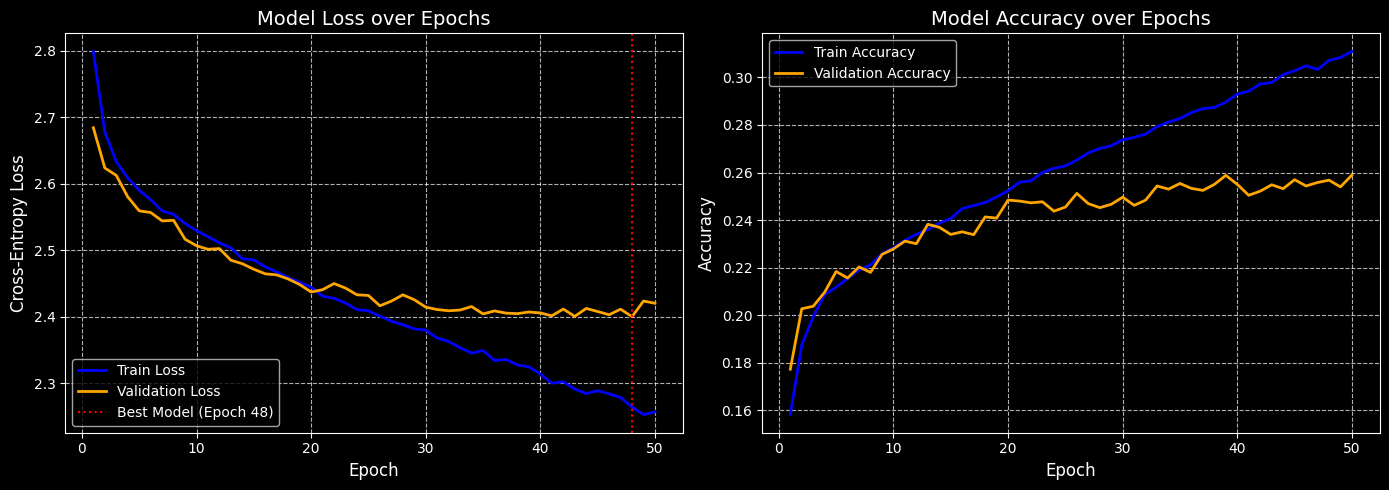

In [27]:
import json
import matplotlib.pyplot as plt

# 1. Load the history data
with open('outputs/training_history.json', 'r') as f:
    history = json.load(f)

epochs = range(1, len(history['train_loss']) + 1)

# 2. Set up the matplotlib figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 3. Plot Loss Curve
ax1.plot(epochs, history['train_loss'], label='Train Loss', color='blue', linewidth=2)
ax1.plot(epochs, history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
ax1.set_title('Model Loss over Epochs', fontsize=14)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Cross-Entropy Loss', fontsize=12)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# 4. Plot Accuracy Curve
ax2.plot(epochs, history['train_acc'], label='Train Accuracy', color='blue', linewidth=2)
ax2.plot(epochs, history['val_acc'], label='Validation Accuracy', color='orange', linewidth=2)
ax2.set_title('Model Accuracy over Epochs', fontsize=14)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

# 5. Highlight the Early Stopping Point (Best Model)
best_epoch = history['val_loss'].index(min(history['val_loss'])) + 1
ax1.axvline(x=best_epoch, color='red', linestyle=':', label=f'Best Model (Epoch {best_epoch})')
ax1.legend()

plt.tight_layout()
plt.show()